In [42]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('ggplot')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (12, 8),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC") 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [43]:
import rateslib as rl
import QuantLib as ql

from Query.IRSwaps.IRSwapQuery import IRSwapQuery, IRSwapStructure
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB, IRSwapValueFunctionMap 
from Query.IRSwaps.IRSwapStructure import IRSwapStructureFunctionMap
from Query.IRSwaps.IRSwapValue import IRSwapValue

from utils.ql_utils import datetime_to_ql_date, ql_date_to_datetime 

In [44]:
# import logging, sys
# for h in logging.root.handlers[:]:
#     logging.root.removeHandler(h)
# logging.basicConfig(
#     level=logging.ERROR,  # or DEBUG
#     stream=sys.stdout,  # send logs to the cell output
#     format="%(asctime)s %(levelname)s [%(name)s] %(message)s",
# )
# logging.getLogger("IRSwapsTB").setLevel(logging.ERROR)
# logging.captureWarnings(True)

import logging
logging.disable(logging.CRITICAL)

In [11]:
# 2025-09-20 18:09:30,966 CRITICAL [ZODB.DB] DB.open() has 19 open connections with a pool_size of 7

In [45]:
# curve_mdp = IRSwapsMDP(source="CME_NY_EOD_LIVE-ql_basic")
# curve_mdp = IRSwapsMDP(source="GSQUANT-rl_basic")
# curve_mdp = IRSwapsMDP(source="SDR_INTRADAY-rl_usd_sofr_mt_q12")
# curve_mdp = IRSwapsMDP(source="SDR_INTRADAY-rl_usd_sofr_mt_misc")
curve_mdp = IRSwapsMDP(source="SDR_INTRADAY-rl_usd_sofr_mtv2_q12x11")
# curve_mdp = IRSwapsMDP(source="SDR_INTRADAY-rl_usd_ois_stir_q12x12", force_refresh_fixings=False)
# irs_tb = IRSwapsTB(mdp=curve_mdp, force_refresh=True)

(<Figure size 1200x800 with 1 Axes>,
 <Axes: >,
 [<matplotlib.lines.Line2D at 0x23aa140d1d0>])

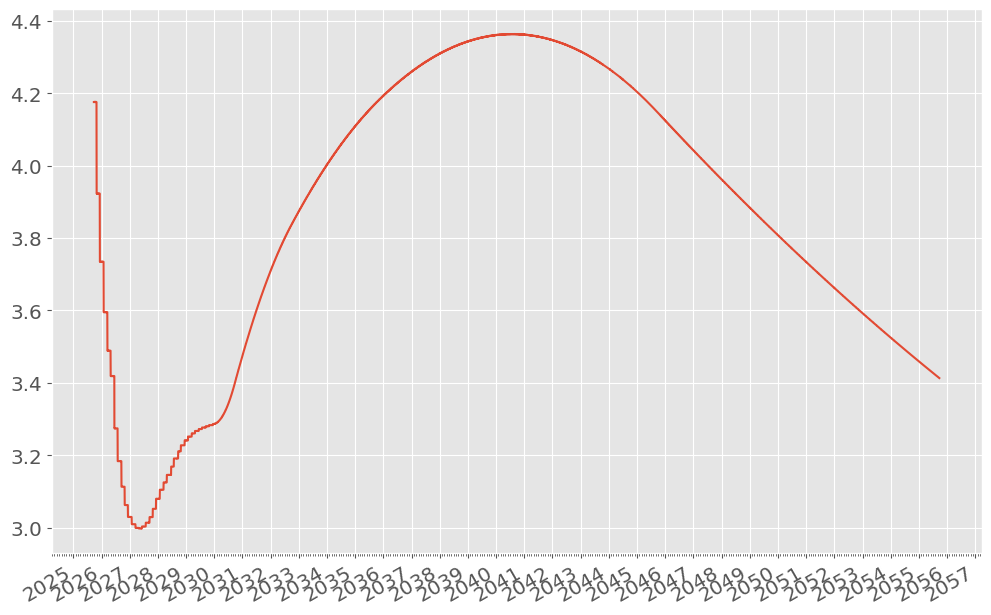

In [46]:
ts = NY_tz.localize(datetime.datetime(2025, 9, 24, 7, 00))
# ts = "live"

curve_handle = curve_mdp._get_curve(curve_name="USD-SOFR-1D", timestamp=ts)

curve_handle.handle().plot("1d")

In [64]:
#  tss = [
#     NY_tz.localize(datetime.datetime(2025, 9, 19, 7, 00)),
#     NY_tz.localize(datetime.datetime(2025, 9, 19, 8, 00)),
#     NY_tz.localize(datetime.datetime(2025, 9, 19, 9, 00)),
#     NY_tz.localize(datetime.datetime(2025, 9, 19, 10, 00)),
#     NY_tz.localize(datetime.datetime(2025, 9, 19, 11, 00)),
#     NY_tz.localize(datetime.datetime(2025, 9, 19, 12, 00)),
#     NY_tz.localize(datetime.datetime(2025, 9, 19, 13, 00)),
#     NY_tz.localize(datetime.datetime(2025, 9, 19, 14, 00)),
#     NY_tz.localize(datetime.datetime(2025, 9, 19, 15, 00)),
#     NY_tz.localize(datetime.datetime(2025, 9, 19, 16, 00)),
#     NY_tz.localize(datetime.datetime(2025, 9, 19, 17, 00)),
#     # "live"
# ]

tss = pd.date_range(start=NY_tz.localize(datetime.datetime(2025, 9, 17, 7, 00)), end=NY_tz.localize(datetime.datetime(2025, 9, 17, 17, 00)), freq="1min")
tss

DatetimeIndex(['2025-09-17 07:00:00-04:00', '2025-09-17 07:01:00-04:00',
               '2025-09-17 07:02:00-04:00', '2025-09-17 07:03:00-04:00',
               '2025-09-17 07:04:00-04:00', '2025-09-17 07:05:00-04:00',
               '2025-09-17 07:06:00-04:00', '2025-09-17 07:07:00-04:00',
               '2025-09-17 07:08:00-04:00', '2025-09-17 07:09:00-04:00',
               ...
               '2025-09-17 16:51:00-04:00', '2025-09-17 16:52:00-04:00',
               '2025-09-17 16:53:00-04:00', '2025-09-17 16:54:00-04:00',
               '2025-09-17 16:55:00-04:00', '2025-09-17 16:56:00-04:00',
               '2025-09-17 16:57:00-04:00', '2025-09-17 16:58:00-04:00',
               '2025-09-17 16:59:00-04:00', '2025-09-17 17:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', length=601, freq='min')

In [66]:
bulk_curves = curve_mdp.bulk_get_data(request={"curve_name": "USD-SOFR-1D", "timestamps": tss, "max_workers": 10, "force_refresh": False})

In [68]:
tens = rl.IRS(effective=rl.dt(2025, 9, 19), termination=rl.dt(2035, 9, 19), spec="usd_irs")

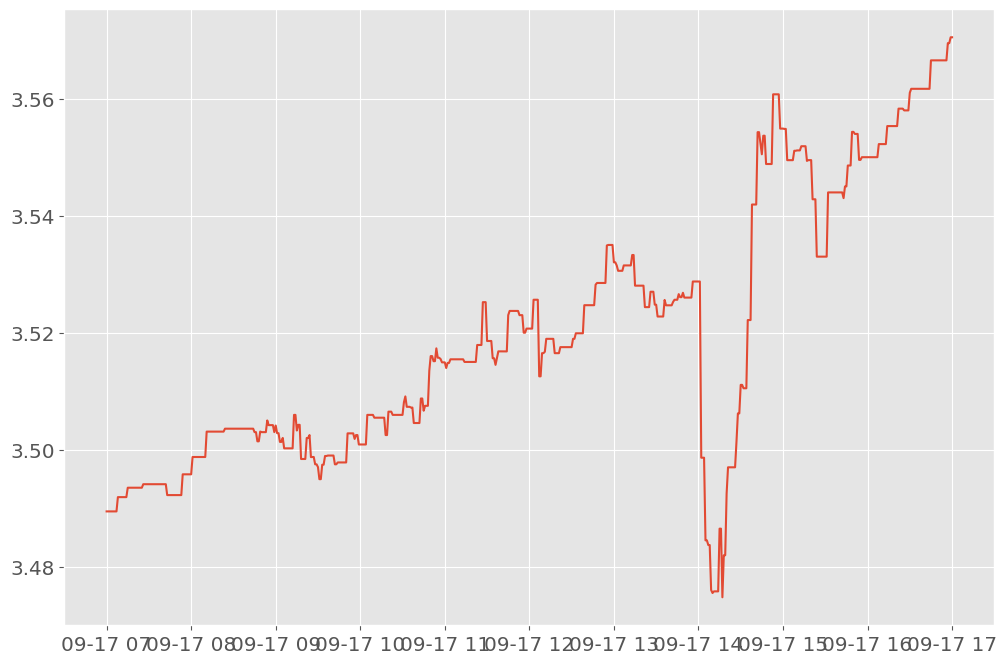

In [69]:
id_ts = [tens.rate(curves=c.handle()).real for c in bulk_curves.values()]
plt.plot(bulk_curves.keys(), id_ts)